# Telescopic OTA
## Notebook Author: Rosnel Leyva-Cortes
This notebook is an example for how to design a telescopic operational transconductance amplifier from python description, to netlist, to layout using the SKY130 process technology.

Note for future implementations: There is a notably more reliable layout generation when using X-cells in PySpice compared to just using a standard M# formatting for transistors. I don't have much time to figure out why but this is notable behavior to explore further.

# Checking Imports 

In [1]:
import os 
import PySpice.Spice.Simulation
import subprocess
import gdstk
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

from PySpice.Spice.Netlist import Circuit
from PySpice.Unit import *
from pathlib import Path

PySpice.Spice.Simulation.CircuitSimulator.DEFAULT_SIMULATOR = 'ngspice-shared'

# Haven't figured out how to port these paths onto system calls, but good to keep track of
ALIGN_PDK_DIR = './ALIGN-public/pdks/SKY130_PDK/'
ALIGN_NET_DIR = './ALIGN_WORK_DIR/'
GDS_OUTPUT_DIR = 'ALIGN_WORK_DIR/GDS_OUT'

# Function and Class Definition

In [2]:
#pyspice to align port 
def export_circuit_to_align(circuit, align_dir='ALIGN_WORK_DIR', cell_name='my_circuit'):
    """
    Exports a PySpice circuit to a SPICE netlist compatible with ALIGN.

    Parameters:
    - circuit: PySpice Circuit object
    - align_dir: str, path to ALIGN working directory
    - cell_name: str, name of the circuit (also used as subckt name and folder name)
    """
    #from PySpice.Spice.Netlist import Circuit

    if not isinstance(circuit, Circuit):
        raise ValueError("Expected a PySpice Circuit object.")

    # Create target directory
    cell_dir = Path(align_dir) / cell_name
    cell_dir.mkdir(parents=True, exist_ok=True)

    # Format the netlist string
    netlist_lines = str(circuit).splitlines()

    # Remove .include or .lib lines (ALIGN doesn't need models here)
    netlist_lines = [line for line in netlist_lines if not line.strip().lower().startswith(('.include', '.lib', '.param', '.control'))]

    # Ensure netlist is wrapped in a .subckt block if not already
    has_subckt = any(line.lower().startswith('.subckt') for line in netlist_lines)
    if not has_subckt:
        # Collect all nodes involved (rough heuristic)
        nodes = set()
        for line in netlist_lines:
            tokens = line.split()
            if tokens and tokens[0][0].upper() in 'MRCLX':
                nodes.update(tokens[1:-1])
        ports = ' '.join(sorted(nodes - {'vdd', 'vss', 'gnd'}))
        netlist_lines.insert(0, f'.subckt {cell_name} {ports}')
        netlist_lines.append(f'.ends {cell_name}')

    # Write to file
    netlist_path = cell_dir / f'{cell_name}.sp'
    with open(netlist_path, 'w') as f:
        f.write('\n'.join(netlist_lines))

    print(f" 😆 Netlist exported for ALIGN: {netlist_path}")

In [3]:
def make_telescopic_ota(wn, wp, l, vdd=1.8, ibias=10e-6):
    circuit = Circuit('Telescopic OTA')

    # Load Sky130 model
    circuit.lib('pySpiceLibrary/skywater-pdk/libraries/sky130_fd_pr/latest/models/sky130.lib.spice', 'tt')

    # Differential pair M1/M2
    circuit.X('M1', 'sky130_fd_pr__nfet_01v8', 'n1', 'vinp', 'tail', 'vss', w=wn, l=l)
    circuit.X('M2', 'sky130_fd_pr__nfet_01v8', 'n2', 'vinm', 'tail', 'vss', w=wn, l=l)

    # NMOS cascodes M6/M7
    circuit.X('M6', 'sky130_fd_pr__nfet_01v8', 'n6', 'bias67', 'n1', 'vss', w=wn, l=l)
    circuit.X('M7', 'sky130_fd_pr__nfet_01v8', 'vout', 'bias67', 'n2', 'vss', w=wn, l=l)

    # PMOS load M3/M4
    circuit.X('M3', 'sky130_fd_pr__pfet_01v8_hvt', 'n3', 'n6', 'vdd', 'vdd', w=wp, l=l)
    circuit.X('M4', 'sky130_fd_pr__pfet_01v8_hvt', 'n4', 'n6', 'vdd', 'vdd', w=wp, l=l)

    # PMOS cascodes M8/M9
    circuit.X('M8', 'sky130_fd_pr__pfet_01v8_hvt', 'n6', 'bias89', 'n3', 'vdd', w=wp, l=l)
    circuit.X('M9', 'sky130_fd_pr__pfet_01v8_hvt', 'vout', 'bias89', 'n4', 'vdd', w=wp, l=l)

    # Tail current source M5
    circuit.X('M5', 'sky130_fd_pr__nfet_01v8', 'tail', 'bias5', 'vss', 'vss', w=wn, l=l)

    # Load resistor for testing (optional)
    #circuit.R('L', 'vout', circuit.gnd, 10@u_kΩ)

    return circuit

# Circuit Definition

In [4]:
ota = make_telescopic_ota(wn=840e-9, wp=840e-9, l=150e-9)
print(ota)

.title Telescopic OTA
.lib /PIACC/pySpiceLibrary/skywater-pdk/libraries/sky130_fd_pr/latest/models/sky130.lib.spice tt
XM1 n1 vinp tail vss sky130_fd_pr__nfet_01v8 l=1.5e-07 w=8.4e-07
XM2 n2 vinm tail vss sky130_fd_pr__nfet_01v8 l=1.5e-07 w=8.4e-07
XM6 n6 bias67 n1 vss sky130_fd_pr__nfet_01v8 l=1.5e-07 w=8.4e-07
XM7 vout bias67 n2 vss sky130_fd_pr__nfet_01v8 l=1.5e-07 w=8.4e-07
XM3 n3 n6 vdd vdd sky130_fd_pr__pfet_01v8_hvt l=1.5e-07 w=8.4e-07
XM4 n4 n6 vdd vdd sky130_fd_pr__pfet_01v8_hvt l=1.5e-07 w=8.4e-07
XM8 n6 bias89 n3 vdd sky130_fd_pr__pfet_01v8_hvt l=1.5e-07 w=8.4e-07
XM9 vout bias89 n4 vdd sky130_fd_pr__pfet_01v8_hvt l=1.5e-07 w=8.4e-07
XM5 tail bias5 vss vss sky130_fd_pr__nfet_01v8 l=1.5e-07 w=8.4e-07



# Layout Definition

In [5]:
export_circuit_to_align(ota, align_dir=ALIGN_NET_DIR, cell_name='telescopic_OTA_example')

 😆 Netlist exported for ALIGN: ALIGN_WORK_DIR/telescopic_OTA_example/telescopic_OTA_example.sp


In [7]:
!schematic2layout.py './ALIGN_WORK_DIR/telescopic_OTA_example' -p '/ALIGN-public/pdks/SKY130_PDK/' -w './ALIGN_WORK_DIR/GDS_OUT'

align.main INFO : Reading netlist: /PIACC/ALIGN_WORK_DIR/telescopic_OTA_example/telescopic_OTA_example.sp subckt=TELESCOPIC_OTA_EXAMPLE, flat=0
align.compiler.compiler INFO : Starting topology identification...
align.compiler.compiler INFO : Power and ground nets not found. Power grid will not be constructed.
align.compiler.compiler INFO : Completed topology identification.
align.cell_fabric.drc ERROR : Found errors: DRC 2
align.cell_fabric.drc ERROR : Found errors: DRC 2
align.pnr.main INFO : Running Place & Route for TELESCOPIC_OTA_EXAMPLE
align.pnr.build_pnr_model INFO : Reading contraint json file TELESCOPIC_OTA_EXAMPLE.pnr.const.json
align.pnr.build_pnr_model INFO : Reading contraint json file CASCODED_CMC_PMOS_52737575.pnr.const.json
align.pnr.build_pnr_model INFO : Reading contraint json file TELESCOPIC_OTA_EXAMPLE.pnr.const.json
align.pnr.build_pnr_model INFO : Reading contraint json file CASCODED_CMC_PMOS_52737575.pnr.const.json
align.pnr.placer INFO : Starting bottom-up place

# Output GDS should look like this 
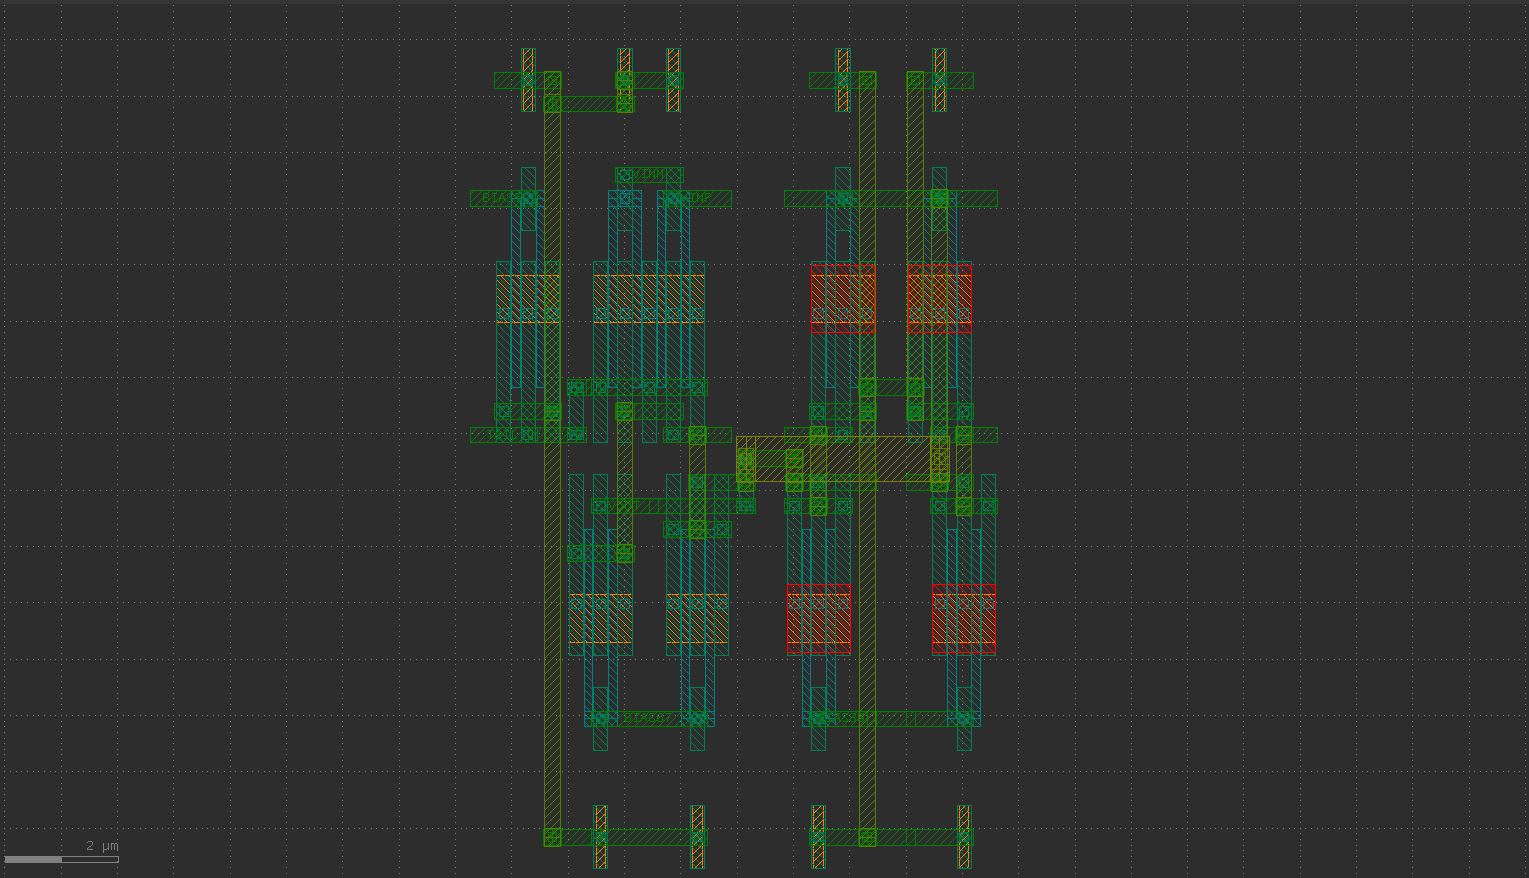